In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# Load data
import pandas as pd
df = pd.read_csv(r"C:\Users\hp\Desktop\Projects(DS)\IMDB\imdb_movies_final_clean.csv")
df

,Movie_Title,Genre,Rating,Votes,Popularity_Score,Region,Gross_Proxy
0,The Rip,Action,6.8,75000.0,510000.0,Bollywood,510000.0
1,Sinners,Action,7.5,376000.0,2820000.0,Others,2820000.0
2,One Battle After Another,Action,7.8,299000.0,2332200.0,Others,2332200.0
3,Mercy,Action,6.2,5900.0,36580.0,Bollywood,36580.0
4,Avatar: Fire and Ash,Action,7.4,121000.0,895400.0,Bollywood,895400.0
...,...,...,...,...,...,...,...
509,The Tale of Silyan,Documentary,7.4,547.0,4047.8,Bollywood,4047.8
510,The AI Doc: Or How I Became an Apocaloptimist,Documentary,8.3,6.0,49.8,Bollywood,49.8
511,My Octopus Teacher,Documentary,8.1,70000.0,567000.0,Bollywood,567000.0
512,The Dawn Wall,Documentary,8.1,22000.0,178200.0,Bollywood,178200.0


In [18]:
# Create target variable
median_gross = df["Gross_Proxy"].median()

df["Success"] = df["Gross_Proxy"].apply(
    lambda x: 1 if x > median_gross else 0
)

In [19]:
# Drop unnecessary columns
df = df.drop("Movie_Title", axis=1)

In [20]:
# Encode categorical features
df = pd.get_dummies(df, columns=["Genre","Region"], drop_first=True)

In [21]:
# Define X and y
X = df.drop("Success", axis=1)
y = df["Success"]

In [22]:
# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
# Train model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [24]:
# predictions
pred = model.predict(X_test)

print(pred[:10])

[0 0 1 0 0 0 1 0 1 1]


In [25]:
# Compare predictions with actual values
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": pred
})

comparison.head(15)

,Actual,Predicted
304,0,0
497,0,0
440,1,1
153,0,0
499,0,0
131,0,0
204,1,1
508,0,0
325,1,1
247,1,1


In [26]:
# Prediction probabilities
probs = model.predict_proba(X_test)

print(probs[:5])

[[9.99998734e-01 1.26648049e-06]
 [9.99999978e-01 2.18446169e-08]
 [0.00000000e+00 1.00000000e+00]
 [9.99999819e-01 1.81324320e-07]
 [9.99800090e-01 1.99910005e-04]]


In [27]:
comparison["Hit_Probability"] = probs[:,1]
comparison.head()

,Actual,Predicted,Hit_Probability
304,0,0,1.266480e-06
497,0,0,2.184462e-08
440,1,1,1.000000e+00
153,0,0,1.813243e-07
499,0,0,1.999100e-04


In [28]:
# Predict on new movie
new_movie = X_test.iloc[[0]]
model.predict(new_movie)

array([0])

In [29]:
model.predict_proba(new_movie)

array([[9.99998734e-01, 1.26648049e-06]])

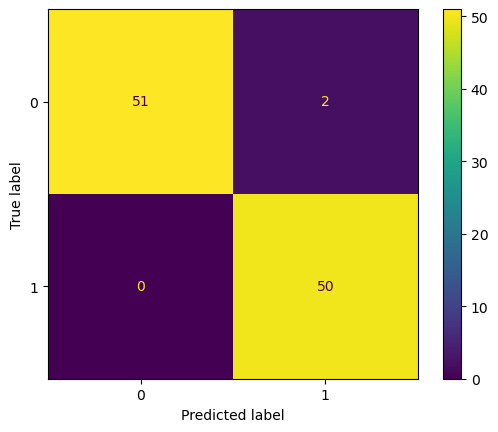

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [31]:
# Evaluate
from sklearn.metrics import accuracy_score, classification_report

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.9805825242718447
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        53
           1       0.96      1.00      0.98        50

    accuracy                           0.98       103
   macro avg       0.98      0.98      0.98       103
weighted avg       0.98      0.98      0.98       103

